In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src')
from utils.utils import CreateTimeFrames

In [3]:
STOCK = 'ETH'
TF = '1h'
LEVEL = 1
PRICE = 'close'
SEQ_LENGTH = 48
BATCH_SIZE = 8
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)

In [4]:
df = pd.read_csv(f'data/{STOCK}USD_2023_2024.csv',
                  index_col = 'Gmt time')
df.index = pd.to_datetime(df.index, format='%d.%m.%Y %H:%M:%S.%f', errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})


timeframes = [TF]
# timeframes = ['1min','5min','15min', '30min','1h', '4h','1d','1w','1m']
df = CreateTimeFrames(df,timeframes)
df_tf = df[TF]
df_tf = df_tf.iloc[-4050:,:]


In [5]:
close = df_tf[f'{PRICE}'].to_numpy(dtype=np.int32)
print(f'There are {close.size} {PRICE} prices.')

There are 4050 close prices.


In [6]:
train = close[:int(np.ceil(TRAIN_SPLIT*len(close)))]
val = close[int(np.ceil(TRAIN_SPLIT*len(close))): int(np.ceil( (TRAIN_SPLIT+VAL_SPLIT)*len(close) ))]
test = close[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(close))):]
assert len(train) + len(val) + len(test) == len(df_tf), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df_tf)} "
print(f'train size:{train.size}, val size:{val.size}, test size:{test.size}.')

train size:2835, val size:405, test size:810.


In [7]:
SaveInfo = np.load(f'cnn/{STOCK}_1h/SaveInfo.npy', allow_pickle=True).item()

In [8]:
SaveInfo.keys()

dict_keys(['EpochLoss', 'ValLoss', 'TrainTime'])

In [9]:
TL = SaveInfo.get('EpochLoss')
nonZeroIndex = np.where((TL == 0))[0][0]

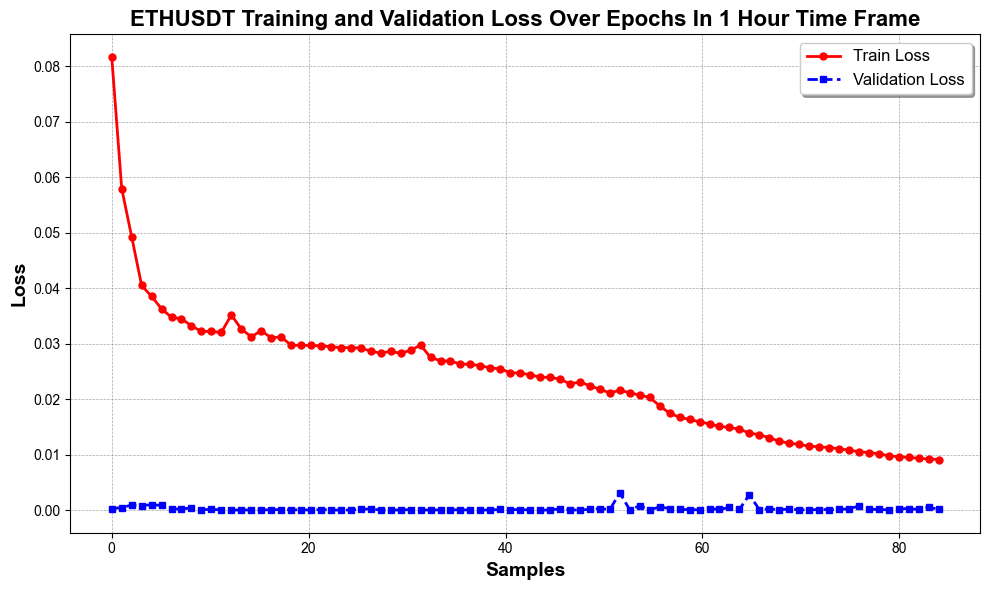

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure consistent fonts
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Example data
t = np.linspace(0, nonZeroIndex, nonZeroIndex)
signal1 = SaveInfo.get('EpochLoss')[0:nonZeroIndex]
signal2 = SaveInfo.get('ValLoss')[0:nonZeroIndex]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data with default matplotlib colors
ax.plot(t, signal1, color='red', linewidth=2, marker='o', markersize=5, label='Train Loss')  # Default blue
ax.plot(t, signal2, color='blue', linewidth=2, linestyle='--', marker='s', markersize=5, label='Validation Loss')  # Default red

# Customize grid and background
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_facecolor('white')

# Set labels and title with better formatting
ax.set_xlabel('Samples', fontsize=14, fontweight='bold')
ax.set_ylabel('Loss', fontsize=14, fontweight='bold')
ax.set_title(f'{STOCK}USDT Training and Validation Loss Over Epochs In 1 Hour Time Frame', fontsize=16, fontweight='bold')

# Customize legend
ax.legend(loc='best', fontsize=12, frameon=True, shadow=True, fancybox=True)

# Improve layout and save the figure
plt.tight_layout()
plt.savefig(f'cnn/{STOCK}_{TF}/figs/TrainValLoss{STOCK}{TF}.png', dpi=300, bbox_inches='tight')
plt.show()
